This tutorial is designed as a hands-on, computational introduction to Boolean
network modeling using BoolForge.

Rather than focusing purely on theory, we emphasize executable workflows and 
reproducible experiments. The goal is to enable readers to explore structure-dynamics
relationships directly through code.

To illustrate the type of analyses enabled by BoolForge, we begin with a simple
example reproducing Derrida's classical phase transition (see 
@derrida1986random) in a few lines of BoolForge code.

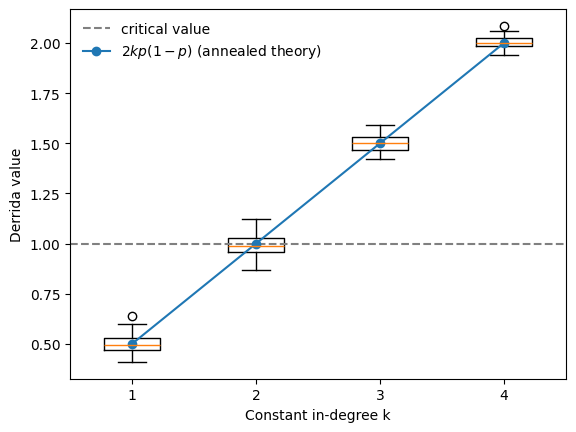

In [1]:
import boolforge as bf
import matplotlib.pyplot as plt

N = 100          # network size
ks = range(1,5)  # constant in-degree
n_networks = 50  # ensemble size
p = 0.5          # bias p: probability of ones in truth table

derrida_values = []
for k in ks:
    derrida_values.append([])
    for _ in range(n_networks):
        bn = bf.random_network(N, k, bias = p, allow_degenerate_functions=True)
        derrida_values[-1].append( bn.get_derrida_value(exact=True) )

plt.boxplot(derrida_values, positions=list(ks))
plt.axhline(1, linestyle="--", color="gray", label="critical value")
plt.plot(ks, [2*k*p*(1-p) for k in ks], "o-", label=r"$2kp(1-p)$ (annealed theory)")
plt.xlabel("Constant in-degree k")
plt.ylabel("Derrida value")
plt.legend(frameon=False);

The Derrida value measures the average number of nodes affected by a single-bit 
random perturbation after one synchronous update of the network.


## Structure of the tutorials {.unnumbered}

The tutorials gradually introduce the main concepts and tools provided by
BoolForge, moving from individual Boolean functions to full Boolean
network models and their dynamical analysis.

- *Boolean functions:* representation and structural analysis
- *Canalization:* redundancy and robustness of regulatory rules
- *Random function generation:* sampling functions with prescribed properties
- *Boolean networks:* construction and wiring diagrams
- *Network dynamics:* attractors and state transition graphs
- *Stability and robustness:* sensitivity to perturbations
- *Random network ensembles:* statistical analysis of network dynamics
- *Biological models:* analysis of curated regulatory networks

Each tutorial contains executable code examples illustrating how these ideas
can be explored using BoolForge. Corresponding Jupyter notebook (ipynb) files
can be found at [https://github.com/ckadelka/BoolForge/tree/main/tutorials](https://github.com/ckadelka/BoolForge/tree/main/tutorials).
Readers are encouraged to run the code cells and modify the examples to
explore their own Boolean functions and networks.